# Analysis

Uses the tables built by the scripts in this directory (see [README.md](README.md)).

In [1]:
import numpy as np
import pandas as pd

survey = pd.read_csv("survey_data.csv", dtype={"session": str})
rounds = pd.read_csv("task_variables.csv", dtype={"session": str})

ARMS = {"Control Group": ["control"], "Treatment Group": ["treatment"], "Overall": ["control", "treatment"]}

## Summary of Experimental Data

In [2]:
ENGLISH_SCALE = {"Low": 1, "Medium-Low": 2, "Medium-High": 3, "High": 4, "Fluent/Native": 5}

demographics = pd.DataFrame({
    "arm": survey["arm"],
    "female": (survey["demographics-survey-q1"] == "Female").astype(float),
    "age": pd.to_numeric(survey["demographics-survey-q2"], errors="coerce"),
    "english": survey["demographics-survey-q63"].map(ENGLISH_SCALE),
    "closeness": pd.to_numeric(survey["demographics-survey-q7"], errors="coerce"),
})


def partner_view(i, j):
    return pd.DataFrame({
        "arm": rounds["arm"],
        "complete": rounds["R"].notna(),
        "u": rounds[f"u_{i}"],
        "P": rounds[f"P_{i}"],
        "N": rounds[f"N_{i}"],
        "N_ij": rounds[f"N_{i}{j}"],
        "S_C": rounds[f"S_{i}"].map({"C": 1.0, "I": 0.0}),
        "V": rounds[f"V_{i}"],
    })


# One row per participant per round; u_i, N_i, N_ij are limited to rounds where both partners' designs registered
individual = pd.concat([partner_view("1", "2"), partner_view("2", "1")], ignore_index=True)
individual.loc[~individual["complete"], ["u", "N", "N_ij"]] = np.nan


def outcome_indicator(code):
    return (rounds["O"] == code).astype(float).where(rounds["O"].notna())


paired = pd.DataFrame({
    "arm": rounds["arm"],
    "R": rounds["R"],
    "delta_u": rounds["delta_u"],
    "O_S": outcome_indicator("S"),
    "O_I": outcome_indicator("I"),
    "O_F": outcome_indicator("F"),
    "E": rounds["E"],
})

In [3]:
SUMMARY_ITEMS = [
    ("Demographic Factors", "Female (Fraction)", demographics, "female"),
    ("Demographic Factors", "Age (Years)", demographics, "age"),
    ("Demographic Factors", "English Proficiency", demographics, "english"),
    ("Demographic Factors", "Social Closeness", demographics, "closeness"),
    ("Derived Task Attributes", "Normalized Deviation Loss (u_i)", individual, "u"),
    ("Derived Task Attributes", "Risk Dominance (R)", paired, "R"),
    ("Derived Task Attributes", "Risk Threshold Asymmetry (Δu)", paired, "delta_u"),
    ("Individual Observations", "Collaboration Belief (P_i)", individual, "P"),
    ("Individual Observations", "Collab. Intention (N_i)", individual, "N"),
    ("Individual Observations", "Partner Collab. Intent. (N_ij)", individual, "N_ij"),
    ("Individual Observations", "Collab. Strategy (S_i = C)", individual, "S_C"),
    ("Individual Observations", "Realized Payoff (V_i)", individual, "V"),
    ("Paired Observations", "Successful Collab. (O = O_S)", paired, "O_S"),
    ("Paired Observations", "Mutual Indep. (O = O_I)", paired, "O_I"),
    ("Paired Observations", "Coord. Failure (O = O_F)", paired, "O_F"),
    ("Paired Observations", "Payoff Efficiency (E)", paired, "E"),
]


def summarize(values):
    values = values.dropna()
    return {"n": len(values), "Mean": values.mean(), "SE": values.sem()}


summary = pd.DataFrame(
    [
        {
            (group, stat): value
            for group, arms in ARMS.items()
            for stat, value in summarize(data.loc[data["arm"].isin(arms), column]).items()
        }
        for _, _, data, column in SUMMARY_ITEMS
    ],
    index=pd.MultiIndex.from_tuples(
        [(section, item) for section, item, _, _ in SUMMARY_ITEMS], names=["Section", "Item"]
    ),
)
summary.columns = pd.MultiIndex.from_tuples(summary.columns)
summary.round(4)

Control Group  \
                                                                    n   
Section                 Item                                            
Demographic Factors     Female (Fraction)                          24   
                        Age (Years)                                24   
                        English Proficiency                        23   
                        Social Closeness                           23   
Derived Task Attributes Normalized Deviation Loss (u_i)           716   
                        Risk Dominance (R)                        358   
                        Risk Threshold Asymmetry (Δu)             358   
Individual Observations Collaboration Belief (P_i)                720   
                        Collab. Intention (N_i)                   716   
                        Partner Collab. Intent. (N_ij)            716   
                        Collab. Strategy (S_i = C)                718   
                        Realized Payoff (V_i)                     716   
Paired Observations     Successful Collab. (O = O_S)              358   
                        Mutual Indep. (O = O_I)                   358   
                        Coord. Failure (O = O_F)                  358   
                        Payoff Efficiency (E)                     358   

                                                                          \
                                                            Mean      SE   
Section                 Item                                               
Demographic Factors     Female (Fraction)                 0.2917  0.0948   
                        Age (Years)                      27.0417  1.0572   
                        English Proficiency               4.2609  0.1436   
                        Social Closeness                  1.6522  0.2232   
Derived Task Attributes Normalized Deviation Loss (u_i)   0.7074  0.0040   
                        Risk Dominance (R)                0.9403  0.0180   
                        Risk Threshold Asymmetry (Δu)     0.1418  0.0042   
Individual Observations Collaboration Belief (P_i)       65.1667  1.1342   
                        Collab. Intention (N_i)          -5.3531  1.2610   
                        Partner Collab. Intent. (N_ij)   -5.3531  1.2171   
                        Collab. Strategy (S_i = C)        0.7187  0.0168   
                        Realized Payoff (V_i)            77.3715  2.0771   
Paired Observations     Successful Collab. (O = O_S)      0.6341  0.0255   
                        Mutual Indep. (O = O_I)           0.1927  0.0209   
                        Coord. Failure (O = O_F)          0.1732  0.0200   
                        Payoff Efficiency (E)             0.4106  0.0397   

                                                        Treatment Group  \
                                                                      n   
Section                 Item                                              
Demographic Factors     Female (Fraction)                            28   
                        Age (Years)                                  28   
                        English Proficiency                          27   
                        Social Closeness                             27   
Derived Task Attributes Normalized Deviation Loss (u_i)             840   
                        Risk Dominance (R)                          420   
                        Risk Threshold Asymmetry (Δu)               420   
Individual Observations Collaboration Belief (P_i)                  840   
                        Collab. Intention (N_i)                     840   
                        Partner Collab. Intent. (N_ij)              840   
                        Collab. Strategy (S_i = C)                  840   
                        Realized Payoff (V_i)                       840   
Paired Observations     Successful Collab. (O = O_S)                420   
                       

### Demographic balance between arms

Fisher's exact test for gender, Welch's $t$-test for age, and two-sided Mann-Whitney $U$ tests
(treatment vs. control) for English proficiency and social closeness.

In [4]:
from scipy import stats


def mann_whitney_z(x, y, u):
    # Tie-corrected normal approximation, without continuity correction
    n_x, n_y = len(x), len(y)
    _, tie_counts = np.unique(stats.rankdata(np.concatenate([x, y])), return_counts=True)
    n = n_x + n_y
    variance = n_x * n_y / 12 * ((n + 1) - (tie_counts**3 - tie_counts).sum() / (n * (n - 1)))
    return (u - n_x * n_y / 2) / np.sqrt(variance)


control = demographics[demographics["arm"] == "control"]
treatment = demographics[demographics["arm"] == "treatment"]

gender = stats.fisher_exact(pd.crosstab(demographics["arm"], demographics["female"]).values)
age = stats.ttest_ind(control["age"], treatment["age"], equal_var=False)
balance = [
    {"Factor": "Female", "Test": "Fisher's exact", "Statistic": np.nan, "df": np.nan, "z": np.nan, "p": gender.pvalue},
    {"Factor": "Age", "Test": "Welch's t", "Statistic": age.statistic, "df": age.df, "z": np.nan, "p": age.pvalue},
]
for factor, column in [("English Proficiency", "english"), ("Social Closeness", "closeness")]:
    x, y = treatment[column].dropna().values, control[column].dropna().values
    test = stats.mannwhitneyu(x, y, alternative="two-sided")
    balance.append({
        "Factor": factor, "Test": "Mann-Whitney U", "Statistic": test.statistic, "df": np.nan,
        "z": mann_whitney_z(x, y, test.statistic), "p": test.pvalue,
    })

pd.DataFrame(balance).set_index("Factor").round(3)

,Test,Statistic,df,z,p
Factor,,,,,
Female,Fisher's exact,NaN,NaN,NaN,1.000
Age,Welch's t,1.359,40.735,NaN,0.182
English Proficiency,Mann-Whitney U,290.000,NaN,-0.439,0.669
Social Closeness,Mann-Whitney U,377.500,NaN,1.479,0.142


## Categorical Outcomes

Binomial GEE models of round outcome, fit separately per contrast against successful
collaboration (reference category):

$$\log\left(\frac{P(O = O_I)}{P(O = O_S)}\right) = \beta_0 + \beta_1 T + \beta_2 R + \beta_3 \Delta u + \beta_4 (T \times \Delta u)$$

$$\log\left(\frac{P(O = O_F)}{P(O = O_S)}\right) = \beta_0 + \beta_1 T + \beta_2 R + \beta_3 \Delta u + \beta_4 (T \times \Delta u)$$

Exchangeable working correlation, cluster-robust standard errors on pair. $R$ and $\Delta u$ are
centered to zero mean over all rounds with an observed outcome.

In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_data = rounds[rounds["O"].notna()].copy()
model_data["pair"] = model_data["arm"] + "_" + model_data["session"] + "_" + model_data["username_1"]
model_data["T"] = (model_data["arm"] == "treatment").astype(float)
model_data["R"] = model_data["R"] - model_data["R"].mean()
model_data["delta_u"] = model_data["delta_u"] - model_data["delta_u"].mean()

TERMS = {"Intercept": "Intercept", "T": "T", "R": "R", "delta_u": "Δu", "T:delta_u": "T × Δu"}


def fit_gee(formula, data, family, **fit_kwargs):
    # Fully iterated GEE (alternating mean and dependence updates to convergence). The paper's
    # reported values are reproduced by fit(params_niter=100) instead, which converges the mean
    # parameters before alpha is re-estimated, leaving alpha at its estimate from the initial
    # independence fit (e.g., 0.324 vs 0.365 for the O_I contrast). Pass fit_kwargs to override.
    model = smf.gee(formula, groups="pair", data=data, family=family, cov_struct=sm.cov_struct.Exchangeable())
    return model.fit(**fit_kwargs)


def coefficient_table(result):
    return pd.DataFrame(
        {"Coef.": result.params, "SE": result.bse, "z": result.tvalues, "p": result.pvalues}
    ).rename(index=TERMS)


def fit_info(result):
    return {
        "n": int(result.nobs),
        "clusters": result.model.num_group,
        "alpha": result.cov_struct.dep_params,
    }

In [6]:
CONTRASTS = {"Mutual independence (O_I)": "I", "Coordination failure (O_F)": "F"}

outcome_models = {}
for label, outcome in CONTRASTS.items():
    data = model_data[model_data["O"].isin([outcome, "S"])].copy()
    data["y"] = (data["O"] == outcome).astype(float)
    outcome_models[label] = fit_gee("y ~ T + R + delta_u + T:delta_u", data, sm.families.Binomial())

pd.DataFrame([fit_info(result) for result in outcome_models.values()], index=list(outcome_models)).round(3)

,n,clusters,alpha
Mutual independence (O_I),678,26,0.365
Coordination failure (O_F),662,26,0.294


In [7]:
pd.concat({label: coefficient_table(result) for label, result in outcome_models.items()}, axis=1).round(3)

Mutual independence (O_I)                       \
                              Coef.     SE      z      p   
Intercept                    -0.922  0.413 -2.231  0.026   
T                            -1.037  0.824 -1.258  0.208   
R                             2.064  0.354  5.835  0.000   
Δu                            5.086  1.851  2.747  0.006   
T × Δu                       -2.913  2.217 -1.314  0.189   

          Coordination failure (O_F)                       
                               Coef.     SE      z      p  
Intercept                     -1.084  0.414 -2.617  0.009  
T                             -0.817  0.645 -1.266  0.206  
R                              0.949  0.300  3.167  0.002  
Δu                             5.519  1.177  4.690  0.000  
T × Δu                        -4.948  2.287 -2.164  0.031

## Payoff Efficiency

Gaussian GEE model of payoff efficiency with the same covariates, working correlation, and
clustering as the categorical outcome models:

$$E = \beta_0 + \beta_1 T + \beta_2 R + \beta_3 \Delta u + \beta_4 (T \times \Delta u)$$

In [8]:
efficiency_model = fit_gee("E ~ T + R + delta_u + T:delta_u", model_data, sm.families.Gaussian())

pd.DataFrame([fit_info(efficiency_model)], index=["Payoff efficiency (E)"]).round(3)

,n,clusters,alpha
Payoff efficiency (E),778,26,0.361


In [9]:
coefficient_table(efficiency_model).round(3)

,Coef.,SE,z,p
Intercept,0.410,0.119,3.444,0.001
T,0.234,0.164,1.422,0.155
R,-0.338,0.093,-3.614,0.000
Δu,-1.175,0.354,-3.321,0.001
T × Δu,1.190,0.573,2.075,0.038


### Predicted efficiency by risk-threshold mismatch

Predicted $E$ from the payoff efficiency model as a function of $\Delta u$ by arm, with $R$ held at
its sample mean. Shaded bands show 95% confidence intervals from the cluster-robust covariance.

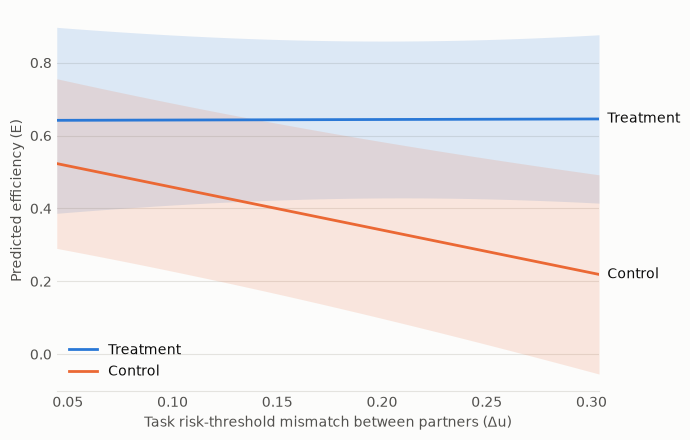

In [10]:
import matplotlib.pyplot as plt

SERIES_COLORS = {"Treatment": "#2a78d6", "Control": "#eb6834"}
INK, MUTED_INK, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"

observed_delta_u = rounds.loc[rounds["O"].notna(), "delta_u"]
delta_u_grid = np.linspace(observed_delta_u.min(), observed_delta_u.max(), 100)
centered_grid = delta_u_grid - observed_delta_u.mean()

params = efficiency_model.params
covariance = efficiency_model.cov_params()
predictions = {}
for label, treated in [("Treatment", 1.0), ("Control", 0.0)]:
    design = pd.DataFrame({
        "Intercept": 1.0, "T": treated, "R": 0.0, "delta_u": centered_grid, "T:delta_u": treated * centered_grid,
    })[params.index]
    mean = design @ params
    se = np.sqrt(np.einsum("ij,jk,ik->i", design, covariance, design))
    predictions[label] = pd.DataFrame({"mean": mean, "lower": mean - 1.96 * se, "upper": mean + 1.96 * se})

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for label, prediction in predictions.items():
    color = SERIES_COLORS[label]
    ax.fill_between(delta_u_grid, prediction["lower"], prediction["upper"], color=color, alpha=0.15, linewidth=0)
    ax.plot(delta_u_grid, prediction["mean"], color=color, linewidth=2, label=label)
    ax.annotate(
        label, (delta_u_grid[-1], prediction["mean"].iloc[-1]), xytext=(6, 0), textcoords="offset points",
        va="center", color=INK, fontsize=10,
    )

ax.set_xlabel("Task risk-threshold mismatch between partners (Δu)", color=MUTED_INK)
ax.set_ylabel("Predicted efficiency (E)", color=MUTED_INK)
ax.set_xlim(delta_u_grid[0], delta_u_grid[-1])
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED_INK, length=0)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.legend(loc="lower left", frameon=False, labelcolor=INK)
fig.tight_layout()
plt.show()

## Collaboration Beliefs

Gaussian GEE model of each participant's reported collaboration belief on their own ($u_i$) and
their partner's ($u_j$) normalized deviation loss:

$$P_i = \beta_0 + \beta_1 T + \beta_2 u_i + \beta_3 u_j$$

One observation per participant per round with an observed outcome, clustered on pair. $u_i$ and
$u_j$ are centered to zero mean over these observations.

In [11]:
def participant_view(i, j):
    return pd.DataFrame({
        "pair": model_data["pair"],
        "username": model_data[f"username_{i}"],
        "T": model_data["T"],
        "delta_u": model_data["delta_u"],
        "u_i": model_data[f"u_{i}"],
        "u_j": model_data[f"u_{j}"],
        "P_i": model_data[f"P_{i}"],
        "P_j": model_data[f"P_{j}"],
        "N_i": model_data[f"N_{i}"],
        "N_ij": model_data[f"N_{i}{j}"],
        "S_i": model_data[f"S_{i}"],
    })


participant_data = pd.concat([participant_view("1", "2"), participant_view("2", "1")], ignore_index=True)
participant_data["arm"] = np.where(participant_data["T"] == 1, "treatment", "control")
participant_data["u_i"] = participant_data["u_i"] - participant_data["u_i"].mean()
participant_data["u_j"] = participant_data["u_j"] - participant_data["u_j"].mean()

TERMS.update({"u_i": "u_i", "u_j": "u_j", "P_i": "P_i", "P_j": "P_j", "N_ij": "N_ij", "T:N_ij": "T × N_ij"})

belief_model = fit_gee("P_i ~ T + u_i + u_j", participant_data, sm.families.Gaussian())

pd.DataFrame([fit_info(belief_model)], index=["Collaboration belief (P_i)"]).round(3)

,n,clusters,alpha
Collaboration belief (P_i),1556,26,0.311


In [12]:
coefficient_table(belief_model).round(3)

,Coef.,SE,z,p
Intercept,65.316,5.098,12.813,0.000
T,19.814,6.002,3.301,0.001
u_i,-36.597,11.433,-3.201,0.001
u_j,-16.467,6.407,-2.570,0.010


## Collaborative Strategies

Chain of binomial GEE models of each participant's strategy. M1 (structural) includes task and
treatment covariates only; M2 adds the participant's own belief $P_i$; M3 adds the partner's
belief $P_j$:

$$\log\left(\frac{P(S_i = C)}{P(S_i = I)}\right) = \beta_0 + \beta_1 T + \beta_2 u_i + \beta_3 \Delta u + \beta_4 (T \times \Delta u)$$

$P_i$ and $P_j$ are centered to zero mean over the same observations as $u_i$ and $u_j$.

In [13]:
strategy_data = participant_data.copy()
strategy_data["y"] = (strategy_data["S_i"] == "C").astype(float)
strategy_data["P_i"] = strategy_data["P_i"] - strategy_data["P_i"].mean()
strategy_data["P_j"] = strategy_data["P_j"] - strategy_data["P_j"].mean()

STRATEGY_FORMULAS = {
    "M1: Structural": "y ~ T + u_i + delta_u + T:delta_u",
    "M2: Own Belief": "y ~ T + P_i + u_i + delta_u + T:delta_u",
    "M3: Partner Belief": "y ~ T + P_i + P_j + u_i + delta_u + T:delta_u",
}

# The fully iterated fit diverges for M3: alpha climbs to 0.777 while the intercept and T drift to
# about -86 and +87, driving every control-arm fitted probability to ~0. All three models instead
# use the paper's warm start (params_niter=20), which converges the mean parameters before alpha
# is re-estimated.
strategy_models = {
    label: fit_gee(formula, strategy_data, sm.families.Binomial(), params_niter=20)
    for label, formula in STRATEGY_FORMULAS.items()
}

pd.DataFrame([fit_info(result) for result in strategy_models.values()], index=list(strategy_models)).round(3)

,n,clusters,alpha
M1: Structural,1556,26,0.320
M2: Own Belief,1556,26,0.229
M3: Partner Belief,1556,26,0.221


In [14]:
STRATEGY_TERMS = ["Intercept", "T", "P_i", "P_j", "u_i", "Δu", "T × Δu"]

pd.concat(
    {label: coefficient_table(result)[["Coef.", "SE", "p"]] for label, result in strategy_models.items()},
    axis=1,
).reindex(STRATEGY_TERMS).round(3)

M1: Structural               M2: Own Belief                \
                   Coef.     SE      p          Coef.     SE      p   
Intercept          0.851  0.364  0.019          1.208  0.291  0.000   
T                  1.002  0.744  0.178          0.463  0.637  0.468   
P_i                  NaN    NaN    NaN          0.031  0.006  0.000   
P_j                  NaN    NaN    NaN            NaN    NaN    NaN   
u_i               -4.927  0.622  0.000         -4.188  0.757  0.000   
Δu                -3.539  1.502  0.019         -4.352  1.657  0.009   
T × Δu             3.807  1.928  0.048          5.007  2.081  0.016   

          M3: Partner Belief                
                       Coef.     SE      p  
Intercept              1.211  0.370  0.001  
T                      0.038  0.590  0.948  
P_i                    0.033  0.006  0.000  
P_j                    0.021  0.005  0.000  
u_i                   -3.969  0.897  0.000  
Δu                    -4.739  1.832  0.010  
T × Δu                 5.542  2.141  0.010

## Mixed-Effects Robustness Checks

Linear mixed-effects models with a random intercept per pair, fit by REML on the same
specifications as the payoff efficiency, collaboration belief, and collaborative strategy GEE
models (linear probability models for the binary strategy outcome). GEE estimates are shown
alongside for comparison.

In [15]:
def fit_lme(formula, data):
    return smf.mixedlm(formula, data, groups=data["pair"]).fit(reml=True)


def lme_comparison(lme, gee):
    return pd.DataFrame({
        ("LME", "Coef."): lme.fe_params,
        ("LME", "SE"): lme.bse_fe,
        ("LME", "p"): lme.pvalues[lme.fe_params.index],
        ("GEE", "Coef."): gee.params,
        ("GEE", "p"): gee.pvalues,
    }).rename(index=TERMS)


LME_MODELS = {
    "Payoff efficiency (E)": ("E ~ T + R + delta_u + T:delta_u", model_data, efficiency_model),
    "Collaboration belief (P_i)": ("P_i ~ T + u_i + u_j", participant_data, belief_model),
    **{
        f"Strategy {label}": (formula, strategy_data, strategy_models[label])
        for label, formula in STRATEGY_FORMULAS.items()
    },
}
lme_models = {label: fit_lme(formula, data) for label, (formula, data, _) in LME_MODELS.items()}
lme_tables = {label: lme_comparison(lme_models[label], gee) for label, (_, _, gee) in LME_MODELS.items()}

In [16]:
pd.concat({label: lme_tables[label] for label in list(LME_MODELS)[:2]}).round(4)

LME                      GEE        
                                        Coef.      SE       p    Coef.       p
Payoff efficiency (E)      Intercept   0.4096  0.1258  0.0011   0.4096  0.0006
                           T           0.2336  0.1714  0.1729   0.2336  0.1550
                           R          -0.3375  0.0578  0.0000  -0.3375  0.0003
                           Δu         -1.1748  0.3615  0.0012  -1.1751  0.0009
                           T × Δu      1.1895  0.4880  0.0148   1.1897  0.0379
Collaboration belief (P_i) Intercept  65.3156  4.4530  0.0000  65.3158  0.0000
                           T          19.8146  6.0682  0.0011  19.8145  0.0010
                           u_i       -36.5968  5.2749  0.0000 -36.5973  0.0014
                           u_j       -16.4661  5.2749  0.0018 -16.4666  0.0102

In [17]:
pd.concat({label: table.reindex(STRATEGY_TERMS) for label, table in lme_tables.items() if label.startswith("Strategy")}).round(4)

LME                     GEE        
                                        Coef.      SE       p   Coef.       p
Strategy M1: Structural     Intercept  0.7195  0.0679  0.0000  0.8512  0.0195
                            T          0.1235  0.0925  0.1820  1.0019  0.1782
                            P_i           NaN     NaN     NaN     NaN     NaN
                            P_j           NaN     NaN     NaN     NaN     NaN
                            u_i       -0.7721  0.0795  0.0000 -4.9274  0.0000
                            Δu        -0.7092  0.1547  0.0000 -3.5387  0.0185
                            T × Δu     0.6662  0.2092  0.0014  3.8068  0.0483
Strategy M2: Own Belief     Intercept  0.7860  0.0563  0.0000  1.2076  0.0000
                            T          0.0006  0.0769  0.9940  0.4629  0.4676
                            P_i        0.0062  0.0004  0.0000  0.0310  0.0000
                            P_j           NaN     NaN     NaN     NaN     NaN
                            u_i       -0.5603  0.0736  0.0000 -4.1877  0.0000
                            Δu        -0.7208  0.1414  0.0000 -4.3516  0.0087
                            T × Δu     0.7405  0.1912  0.0001  5.0074  0.0161
Strategy M3: Partner Belief Intercept  0.8288  0.0553  0.0000  1.2112  0.0011
                            T         -0.0785  0.0756  0.2992  0.0381  0.9484
                            P_i        0.0064  0.0003  0.0000  0.0334  0.0000
                            P_j        0.0038  0.0003  0.0000  0.0208  0.0000
                            u_i       -0.5153  0.0709  0.0000 -3.9691  0.0000
                            Δu        -0.7450  0.1359  0.0000 -4.7388  0.0097
                            T × Δu     0.7876  0.1838  0.0000  5.5421  0.0096

## Strategy Overrides

Rounds where a participant's strategy overrides the sign of their collaborative intention $N_i$:
an **upgrade** to $S_i = C$ despite $N_i \le 0$, or a **downgrade** to $S_i = I$ despite $N_i > 0$,
by the sign of the partner intention $N_{ij}$. Fractions are within each direction and arm.

In [18]:
overrides = participant_data.assign(
    direction=np.select(
        [
            (participant_data["N_i"] <= 0) & (participant_data["S_i"] == "C"),
            (participant_data["N_i"] > 0) & (participant_data["S_i"] == "I"),
        ],
        ["Upgrade", "Downgrade"],
        default="",
    ),
    sgn_N_ij=np.where(participant_data["N_ij"] > 0, "+", "−"),
)
overrides = overrides[overrides["direction"] != ""]

override_counts = (
    overrides.groupby(["direction", "sgn_N_ij", "arm"]).size().unstack("arm")
    .reindex(pd.MultiIndex.from_product([["Upgrade", "Downgrade"], ["+", "−"]], names=["Direction", "sgn(N_ij)"]))
)
override_fractions = override_counts / override_counts.groupby(level="Direction").transform("sum")

pd.concat(
    {
        arm.title(): pd.DataFrame({"Count": override_counts[arm], "Frac.": override_fractions[arm].round(3)})
        for arm in ["control", "treatment"]
    },
    axis=1,
)

Control        Treatment       
                      Count  Frac.     Count  Frac.
Direction sgn(N_ij)                                
Upgrade   +              66  0.340        79  0.963
          −             128  0.660         3  0.037
Downgrade +              21  0.412        19  0.352
          −              30  0.588        35  0.648

### Overriding intention models

Binomial GEE models of overriding one's own intention, fit separately by direction on rounds
with $N_i \le 0$ (upgrade) or $N_i > 0$ (downgrade):

$$\log\left(\frac{P(S_i = C)}{P(S_i = I)}\right) = \beta_0 + \beta_1 T + \beta_2 N_{ij} + \beta_3 (T \times N_{ij}) \quad (N_i \le 0)$$

$$\log\left(\frac{P(S_i = I)}{P(S_i = C)}\right) = \beta_0 + \beta_1 T + \beta_2 N_{ij} + \beta_3 (T \times N_{ij}) \quad (N_i > 0)$$

$N_{ij}$ is centered to zero mean over all participant-round observations.

In [19]:
override_data = participant_data.copy()
override_data["N_ij"] = override_data["N_ij"] - override_data["N_ij"].mean()

OVERRIDE_DIRECTIONS = {
    "Upgrade (N_i ≤ 0 → S_i = C)": (override_data["N_i"] <= 0, "C"),
    "Downgrade (N_i > 0 → S_i = I)": (override_data["N_i"] > 0, "I"),
}

# Fully iterated. The paper's warm start (params_niter=20) gives the same upgrade model but, for the
# downgrade model, alpha = 0.115 (vs 0.143) and N_ij = -0.0316 (vs -0.0319).
override_models = {}
for label, (mask, strategy) in OVERRIDE_DIRECTIONS.items():
    data = override_data[mask].copy()
    data["y"] = (data["S_i"] == strategy).astype(float)
    override_models[label] = fit_gee("y ~ T + N_ij + T:N_ij", data, sm.families.Binomial())

pd.DataFrame([fit_info(result) for result in override_models.values()], index=list(override_models)).round(3)

,n,clusters,alpha
Upgrade (N_i ≤ 0 → S_i = C),503,22,0.441
Downgrade (N_i > 0 → S_i = I),1053,26,0.143


In [20]:
pd.concat({label: coefficient_table(result) for label, result in override_models.items()}, axis=1).round(4)

Upgrade (N_i ≤ 0 → S_i = C)                          \
                                Coef.      SE       z       p   
Intercept                      0.3504  0.3933  0.8909  0.3730   
T                              0.0155  0.6972  0.0223  0.9822   
N_ij                           0.0002  0.0042  0.0429  0.9658   
T × N_ij                       0.0225  0.0089  2.5244  0.0116   

          Downgrade (N_i > 0 → S_i = I)                          
                                  Coef.      SE       z       p  
Intercept                       -2.1990  0.3599 -6.1100  0.0000  
T                               -0.0981  0.5541 -0.1771  0.8595  
N_ij                            -0.0319  0.0082 -3.8891  0.0001  
T × N_ij                        -0.0021  0.0149 -0.1436  0.8858

## Manipulative Behavior

Per-round scores for treatment participants measuring departures from belief-consistent
decisions, taking zero when inactive:

$$UC_i = \begin{cases} N_i & \text{if } N_i > 0 \text{ and } S_i = I \ 0 & \text{otherwise} \end{cases} \qquad
OC_i = \begin{cases} -N_i & \text{if } N_i < 0 \text{ and } S_i = C \ 0 & \text{otherwise} \end{cases}$$

For each participant, a one-sided Mann-Whitney $U$ test (`alternative="greater"`) compares their
scores over all 30 tasks against the pooled scores of all other treatment participants, with a
Benjamini-Hochberg FDR correction within each score across participants. $N_+$ is the number of
tasks with a positive score.

In [21]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

treatment_data = participant_data[participant_data["arm"] == "treatment"].copy()
treatment_data["UC"] = np.where(
    (treatment_data["N_i"] > 0) & (treatment_data["S_i"] == "I"), treatment_data["N_i"], 0.0
)
treatment_data["OC"] = np.where(
    (treatment_data["N_i"] < 0) & (treatment_data["S_i"] == "C"), -treatment_data["N_i"], 0.0
)


def leave_one_out_tests(data, score):
    rows = []
    for username, own in data.groupby("username"):
        others = data.loc[data["username"] != username, score]
        test = mannwhitneyu(own[score], others, alternative="greater")
        rows.append({
            "Participant": int(username.removeprefix("user")),
            "N+": int((own[score] > 0).sum()),
            "Mean": own[score].mean(),
            "U": test.statistic,
            "p": test.pvalue,
        })
    tests = pd.DataFrame(rows)
    tests["p_FDR"] = multipletests(tests["p"], method="fdr_bh")[1]
    return tests.sort_values("p").set_index("Participant")


SCORES = {"Under-Cooperation (UC_i)": "UC", "Over-Cooperation (OC_i)": "OC"}
manipulation_tests = {label: leave_one_out_tests(treatment_data, score) for label, score in SCORES.items()}

print(f"{treatment_data['username'].nunique()} participants, {len(treatment_data)} (participant, round) observations")
pd.concat({label: tests.head(5) for label, tests in manipulation_tests.items()}).style.format(
    {"Mean": "{:.3f}", "U": "{:.1f}", "p": "{:.3g}", "p_FDR": "{:.3g}"}
)

28 participants, 840 (participant, round) observations


### Random-intercept check

Linear mixed-effects model of each score with an intercept and a random intercept per treatment
participant. Each participant's predicted random intercept (BLUP) is divided by its conditional
standard error; participants with $z > 1.96$ are flagged.

In [22]:
def random_intercept_flags(data, score):
    model = smf.mixedlm(f"{score} ~ 1", data, groups=data["username"]).fit(reml=True)
    tau2, sigma2 = model.cov_re.iloc[0, 0], model.scale
    n = data.groupby("username").size()
    blup = pd.Series({username: effect.iloc[0] for username, effect in model.random_effects.items()})
    flags = pd.DataFrame({"BLUP": blup, "z": blup / np.sqrt(tau2 * sigma2 / (n * tau2 + sigma2))})
    flags.index = flags.index.str.removeprefix("user").astype(int).rename("Participant")
    flags["Flagged"] = flags["z"] > 1.96
    return flags.sort_values("z", ascending=False)


random_intercept_checks = {label: random_intercept_flags(treatment_data, score) for label, score in SCORES.items()}
pd.concat({label: flags.head(5) for label, flags in random_intercept_checks.items()}).round(3)

BLUP       z  Flagged
                         Participant                         
Under-Cooperation (UC_i) 31            7.943   9.429     True
                         42            6.383   7.578     True
                         48            4.300   5.104     True
                         61            1.271   1.508    False
                         50            1.053   1.250    False
Over-Cooperation (OC_i)  20           10.467  15.379     True
                         62            6.466   9.501     True
                         22            6.400   9.403     True
                         49            0.905   1.330    False
                         32            0.066   0.097    False